<a href="https://colab.research.google.com/github/ryanglenc/MAT_442/blob/main/MAT_442_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

## 2.2.1 Probability Axioms

The three Kolmogorov axioms:
1. P(A) ≥ 0 for any event A
2. P(S) = 1, where S is the entire sample space
3. For mutually exclusive events, P(A ∪ B) = P(A) + P(B)

We'll verify these axioms using a simple simulated dice roll experiment.

In [2]:
# Sample space: rolling a fair six-sided die
sample_space = [1, 2, 3, 4, 5, 6]
n_trials = 100000
rolls = np.random.choice(sample_space, size=n_trials)

# Empirical probabilities of each outcome
probs = {face: np.mean(rolls == face) for face in sample_space}
print("Empirical probabilities of each face:")
for face, p in probs.items():
    print(f"  P({face}) ≈ {p:.4f}")

# Axiom 1: all probabilities are non-negative
print("\nAxiom 1 (P(A) >= 0):", all(p >= 0 for p in probs.values()))

# Axiom 2: probabilities of the whole sample space sum to 1
total_prob = sum(probs.values())
print("Axiom 2 (P(S) = 1):", np.isclose(total_prob, 1, atol=0.01), f"(sum = {total_prob:.4f})")

# Axiom 3: mutually exclusive events - P(roll is 1 or 2) = P(1) + P(2)
p_1_or_2 = np.mean((rolls == 1) | (rolls == 2))
p_1_plus_p_2 = probs[1] + probs[2]
print(f"\nAxiom 3: P(1 or 2) = {p_1_or_2:.4f}, P(1) + P(2) = {p_1_plus_p_2:.4f}")
print("Match:", np.isclose(p_1_or_2, p_1_plus_p_2, atol=0.01))

Empirical probabilities of each face:
  P(1) ≈ 0.1659
  P(2) ≈ 0.1680
  P(3) ≈ 0.1639
  P(4) ≈ 0.1678
  P(5) ≈ 0.1681
  P(6) ≈ 0.1663

Axiom 1 (P(A) >= 0): True
Axiom 2 (P(S) = 1): True (sum = 1.0000)

Axiom 3: P(1 or 2) = 0.3339, P(1) + P(2) = 0.3339
Match: True


## 2.2.2 Conditional Probability

The conditional probability of A given B is:

P(A | B) = P(A ∩ B) / P(B)

We'll demonstrate this with a simulated deck-of-cards-style example: drawing two cards, checking the probability that the second is a face card given the first was a face card.

In [3]:
# Simulate drawing 2 cards without replacement from a simplified 52-card deck
# Represent each card as (rank, is_face) - 12 face cards, 40 non-face
n_trials = 200000
count_B = 0       # first card is a face card
count_A_and_B = 0 # both cards are face cards

for _ in range(n_trials):
    deck = np.array([1]*12 + [0]*40)  # 1 = face card, 0 = non-face
    np.random.shuffle(deck)
    first, second = deck[0], deck[1]
    if first == 1:
        count_B += 1
        if second == 1:
            count_A_and_B += 1

P_B = count_B / n_trials
P_A_and_B = count_A_and_B / n_trials
P_A_given_B = P_A_and_B / P_B

print(f"P(first card is face) = {P_B:.4f}  (theoretical: {12/52:.4f})")
print(f"P(both face cards) = {P_A_and_B:.4f}  (theoretical: {(12/52)*(11/51):.4f})")
print(f"P(second is face | first is face) = {P_A_given_B:.4f}  (theoretical: {11/51:.4f})")

P(first card is face) = 0.2329  (theoretical: 0.2308)
P(both face cards) = 0.0505  (theoretical: 0.0498)
P(second is face | first is face) = 0.2168  (theoretical: 0.2157)


## 2.2.3 Discrete Random Variables

A discrete random variable takes on a countable set of values, each with an associated probability (its probability mass function, or PMF).

We'll use a **Binomial distribution** as our example: X = number of heads in 10 coin flips, with p = 0.5. We'll compute its PMF, expected value E[X] = np, and variance Var(X) = np(1-p), and compare theory to simulation.

PMF values:
  P(X=0) = 0.0010
  P(X=1) = 0.0098
  P(X=2) = 0.0439
  P(X=3) = 0.1172
  P(X=4) = 0.2051
  P(X=5) = 0.2461
  P(X=6) = 0.2051
  P(X=7) = 0.1172
  P(X=8) = 0.0439
  P(X=9) = 0.0098
  P(X=10) = 0.0010

Theoretical E[X] = 5.0, Var(X) = 2.5
Simulated mean = 4.9954, Simulated variance = 2.4993


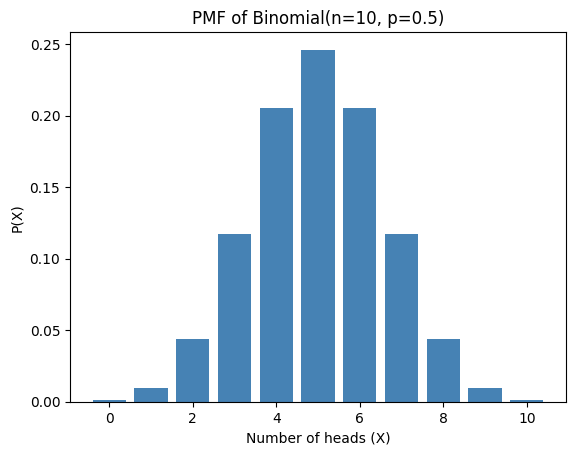

In [4]:
n, p = 10, 0.5
x_vals = np.arange(0, n + 1)

# Theoretical PMF
pmf = stats.binom.pmf(x_vals, n, p)

print("PMF values:")
for x, prob in zip(x_vals, pmf):
    print(f"  P(X={x}) = {prob:.4f}")

# Theoretical mean and variance
mean_theory = n * p
var_theory = n * p * (1 - p)
print(f"\nTheoretical E[X] = {mean_theory}, Var(X) = {var_theory}")

# Simulate
samples = np.random.binomial(n, p, size=100000)
print(f"Simulated mean = {samples.mean():.4f}, Simulated variance = {samples.var():.4f}")

# Plot PMF
plt.bar(x_vals, pmf, color='steelblue')
plt.xlabel('Number of heads (X)')
plt.ylabel('P(X)')
plt.title('PMF of Binomial(n=10, p=0.5)')
plt.show()

## 2.2.4 Continuous Random Variables

A continuous random variable is described by a probability density function (PDF), where probabilities correspond to areas under the curve.

We'll use a **Normal distribution** N(μ=0, σ=1) as our example: plot its PDF, compute P(a ≤ X ≤ b) via integration of the PDF (using the CDF), and verify against simulation.

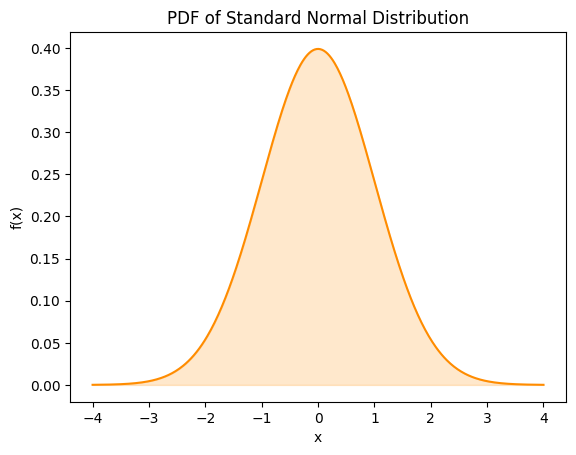

Theoretical P(-1 <= X <= 1) = 0.6827
Simulated P(-1 <= X <= 1) = 0.6828


In [5]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 500)
pdf = stats.norm.pdf(x, mu, sigma)

# Plot the PDF
plt.plot(x, pdf, color='darkorange')
plt.fill_between(x, pdf, alpha=0.2, color='darkorange')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('PDF of Standard Normal Distribution')
plt.show()

# Compute P(-1 <= X <= 1) using the CDF
a, b = -1, 1
prob_theory = stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma)
print(f"Theoretical P({a} <= X <= {b}) = {prob_theory:.4f}")

# Verify via simulation
samples = np.random.normal(mu, sigma, size=200000)
prob_sim = np.mean((samples >= a) & (samples <= b))
print(f"Simulated P({a} <= X <= {b}) = {prob_sim:.4f}")